# 01 - Datos, EDA y problematicas del dataset

Este notebook analiza el dataset antes de entrenar modelos. El objetivo no es producir graficas decorativas, sino justificar decisiones metodologicas: que metricas usar, que riesgos tiene el desbalanceo, por que los documentos largos condicionan la representacion y por que la temporalidad permite estudiar deriva.

Las preguntas que debe responder este EDA son:

1. Cuantos casos hay en `train`, `validation` y `test`.
2. Cuanto miden los textos y si son compatibles con modelos que truncarian secuencias largas.
3. Que articulos son frecuentes o raros.
4. Cuantos articulos aparecen por caso.
5. Si hay cambios temporales en los datos.
6. Que articulos tienden a aparecer juntos.


In [1]:
from pathlib import Path
import json, sqlite3, re, random, math, warnings, sys, subprocess, importlib.util
from datetime import datetime, timezone
from uuid import uuid4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ROOT = Path.cwd().resolve()
DATA = ROOT / 'data'
RAW = DATA / 'raw'
INTERIM = DATA / 'interim'
PROCESSED = DATA / 'processed'
ARTIFACTS = ROOT / 'artifacts'
FIGURES = ARTIFACTS / 'figures'
METRICS = ARTIFACTS / 'metrics'
MODELS = ARTIFACTS / 'models'
INDICES = ARTIFACTS / 'indices'
REPORTS = ARTIFACTS / 'reports'
DB = INTERIM / 'metadata.db'
SCHEMA_PATH = ROOT / 'schema.sql'
for d in [RAW, INTERIM, PROCESSED, FIGURES, METRICS, MODELS, INDICES, REPORTS]:
    d.mkdir(parents=True, exist_ok=True)

def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        package = pip_name or import_name
        print(f'Instalando {package} en este kernel...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

def dump_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def read_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

print('ROOT =', ROOT)


ROOT = C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado


In [2]:
# Celda de autosuficiencia: descarga y materializa el dataset si la base local no existe.
ensure_package('datasets')
from datasets import load_dataset

TASK = 'ecthr_task_b'
DATASET_NAME = 'lex_glue'
DATASET_SUBSET = 'ecthr_b'
CACHE_DIR = RAW / 'hf_cache'

TEXT_KEYS = ('text', 'facts', 'fact', 'document', 'content')
ID_KEYS = ('case_id', 'id', 'doc_id')
YEAR_KEYS = ('year', 'decision_year', 'judgment_year', 'date', 'decision_date', 'judgment_date')

def extract_text_segments(example):
    text_value = ''
    for key in TEXT_KEYS:
        if key in example and example[key] is not None:
            text_value = example[key]
            break
    if isinstance(text_value, str):
        cleaned = text_value.strip()
        return [cleaned] if cleaned else []
    if isinstance(text_value, list):
        return [str(x).strip() for x in text_value if isinstance(x, str) and str(x).strip()]
    return []

def parse_year(value):
    if isinstance(value, bool):
        return None
    if isinstance(value, int) and 1900 <= value <= 2100:
        return value
    if isinstance(value, float) and value.is_integer() and 1900 <= int(value) <= 2100:
        return int(value)
    if isinstance(value, str):
        m = re.search(r'(19|20)\d{2}', value)
        if m:
            return int(m.group(0))
    return None

def extract_year(example):
    for key in YEAR_KEYS:
        if key in example and example[key] is not None:
            y = parse_year(example[key])
            if y is not None:
                return y
    return None

def extract_label_ids(raw_labels, label_count=None):
    if isinstance(raw_labels, (int, float, bool)):
        v = int(raw_labels)
        return [v] if v >= 0 else []
    if not isinstance(raw_labels, (list, tuple)) or len(raw_labels) == 0:
        return []
    values = [int(v) for v in raw_labels if isinstance(v, (int, float, bool))]
    if label_count is not None and len(values) == label_count and set(values).issubset({0, 1}):
        return [i for i, v in enumerate(values) if v == 1]
    return sorted({v for v in values if v >= 0})

def build_case_id(example, task, split, row_idx):
    for key in ID_KEYS:
        if key in example and example[key] is not None:
            safe = re.sub(r'[^A-Za-z0-9_.-]+', '_', str(example[key])).strip('_')
            if safe:
                return f'{task}_{split}_{safe}'
    return f'{task}_{split}_{row_idx:06d}'

def build_case_record(example, task, split, row_idx):
    case_id = build_case_id(example, task, split, row_idx)
    segments = extract_text_segments(example)
    text_full = '\n\n'.join(segments)
    n_tokens = len(re.findall(r'\w+', text_full, flags=re.UNICODE))
    return {
        'case_id': case_id,
        'task': task,
        'split': split,
        'year': extract_year(example),
        'text_full': text_full,
        'n_paragraphs': len(segments),
        'n_tokens': n_tokens,
    }, segments

def extract_label_names(dataset_dict):
    split_name = 'train' if 'train' in dataset_dict else list(dataset_dict.keys())[0]
    features = getattr(dataset_dict[split_name], 'features', None)
    if not features or 'labels' not in features:
        return []
    label_feature = features['labels']
    if hasattr(label_feature, 'feature') and hasattr(label_feature.feature, 'names'):
        return [str(x) for x in label_feature.feature.names]
    if hasattr(label_feature, 'names'):
        return [str(x) for x in label_feature.names]
    return []

def metadata_db_ready(path=DB):
    if not Path(path).exists():
        return False
    try:
        conn = sqlite3.connect(path)
        n_cases = conn.execute('SELECT COUNT(*) FROM cases').fetchone()[0]
        n_labels = conn.execute('SELECT COUNT(*) FROM case_labels').fetchone()[0]
        conn.close()
        return n_cases > 0 and n_labels > 0
    except sqlite3.Error:
        return False

def ensure_metadata_db():
    if metadata_db_ready(DB):
        print(f'Dataset ya preparado en {DB}')
        return
    print('Descargando lex_glue/ecthr_b y creando metadata.db...')
    dataset = load_dataset(DATASET_NAME, DATASET_SUBSET, cache_dir=str(CACHE_DIR))
    label_names = extract_label_names(dataset)
    label_count = len(label_names) if label_names else None
    conn = sqlite3.connect(DB)
    conn.executescript(SCHEMA_PATH.read_text(encoding='utf-8'))
    case_rows, paragraph_rows, label_rows = [], [], []
    discovered_labels = set()
    split_counts = {}
    for split_name in dataset.keys():
        split_counts[split_name] = 0
        for row_idx, example in enumerate(dataset[split_name]):
            case_record, segments = build_case_record(example, task=TASK, split=split_name, row_idx=row_idx)
            case_rows.append(case_record)
            for pidx, paragraph in enumerate(segments):
                paragraph_rows.append({'case_id': case_record['case_id'], 'paragraph_idx': pidx, 'paragraph_text': paragraph})
            labels = extract_label_ids(example.get('labels'), label_count=label_count)
            for label_id in labels:
                discovered_labels.add(label_id)
                label_rows.append({'case_id': case_record['case_id'], 'article_id': str(label_id), 'value': 1})
            split_counts[split_name] += 1
    if label_names:
        article_rows = [{'article_id': str(i), 'article_code': name, 'description': ''} for i, name in enumerate(label_names)]
    else:
        article_rows = [{'article_id': str(i), 'article_code': f'article_{i}', 'description': ''} for i in sorted(discovered_labels)]
    with conn:
        conn.executemany('INSERT OR REPLACE INTO cases VALUES (:case_id, :task, :split, :year, :text_full, :n_paragraphs, :n_tokens)', case_rows)
        conn.executemany('INSERT OR REPLACE INTO case_paragraphs VALUES (:case_id, :paragraph_idx, :paragraph_text)', paragraph_rows)
        conn.executemany('INSERT OR REPLACE INTO articles VALUES (:article_id, :article_code, :description)', article_rows)
        conn.executemany('INSERT OR REPLACE INTO case_labels VALUES (:case_id, :article_id, :value)', label_rows)
        counts = {t: conn.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0] for t in ['cases','case_paragraphs','articles','case_labels','experiment_runs','predictions','explanations']}
    conn.close()
    report = {
        'stage': 'auto_ingestion_from_notebook',
        'timestamp_utc': datetime.now(timezone.utc).isoformat(),
        'dataset': {'name': DATASET_NAME, 'subset': DATASET_SUBSET, 'cache_dir': str(CACHE_DIR)},
        'task': TASK,
        'split_counts': split_counts,
        'inserted': {'articles': len(article_rows), 'cases': len(case_rows), 'case_paragraphs': len(paragraph_rows), 'case_labels': len(label_rows)},
        'table_counts': counts,
        'sqlite_path': str(DB),
    }
    dump_json(report, REPORTS / 'ingestion_status.json')
    print('Dataset preparado:', counts)

ensure_metadata_db()


Dataset ya preparado en C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\data\interim\metadata.db


In [3]:
conn = sqlite3.connect(DB)
cases = pd.read_sql_query('SELECT case_id, split, year, n_paragraphs, n_tokens FROM cases', conn)
labels = pd.read_sql_query('SELECT case_id, article_id, value FROM case_labels WHERE value = 1', conn)
articles = pd.read_sql_query('SELECT article_id, article_code FROM articles', conn)
conn.close()
print(cases.shape, labels.shape, articles.shape)


(11000, 5) (15991, 3) (10, 2)


## Lectura rapida de la estructura real

La siguiente celda resume el volumen real del dataset cargado en SQLite. Tambien calcula cuantas etiquetas positivas hay por caso, que es una medida clave en problemas multietiqueta: si la media es mayor que 1, queda claro que no estamos ante clasificacion multiclase tradicional.


In [4]:
case_label_counts = labels.groupby('case_id').size().rename('n_positive_articles')
shape_summary = pd.DataFrame([{
    'n_cases': len(cases),
    'n_articles': articles['article_id'].nunique(),
    'n_positive_case_article_pairs': len(labels),
    'mean_articles_per_case': round(case_label_counts.mean(), 3),
    'max_articles_in_one_case': int(case_label_counts.max()),
}])
display(shape_summary)


,n_cases,n_articles,n_positive_case_article_pairs,mean_articles_per_case,max_articles_in_one_case
0,11000,10,15991,1.477,7


## Tamano por split

La separacion por split define el protocolo experimental. `train` sirve para aprender vocabulario y pesos del modelo; `validation` sirve para tomar decisiones de ajuste, como los umbrales por etiqueta; `test` se reserva para estimar el comportamiento final.

Esta distincion importa porque usar informacion de `validation` o `test` durante el entrenamiento produciria data leakage: una evaluacion demasiado optimista que no representa un caso nuevo.


In [5]:
split_counts = cases.groupby('split').size().reset_index(name='n_cases')
split_counts.to_csv(METRICS / 'eda_split_counts.csv', index=False)
split_counts


,split,n_cases
0,test,1000
1,train,9000
2,validation,1000


## Longitud de los casos

Los documentos del TEDH son textos largos y heterogeneos. Esta propiedad afecta directamente al diseno del sistema: una representacion que obligue a cortar el texto podria perder hechos relevantes, mientras que TF-IDF permite representar todo el documento como un vector disperso.

La longitud tambien afecta a retrieval y explicabilidad. Casos muy largos pueden compartir mucho vocabulario juridico comun; por eso no basta con mirar similitud textual, tambien se evalua si los precedentes recuperados comparten articulos.


,split,count,mean,std,min,25%,50%,75%,max
0,test,1000.0,1967.142000,1886.732538,104.0,710.75,1441.5,2453.25,16474.0
1,train,9000.0,1652.315333,2032.698632,70.0,490.75,1002.5,2033.25,35780.0
2,validation,1000.0,1823.509000,1843.919457,85.0,611.75,1290.5,2377.50,14847.0


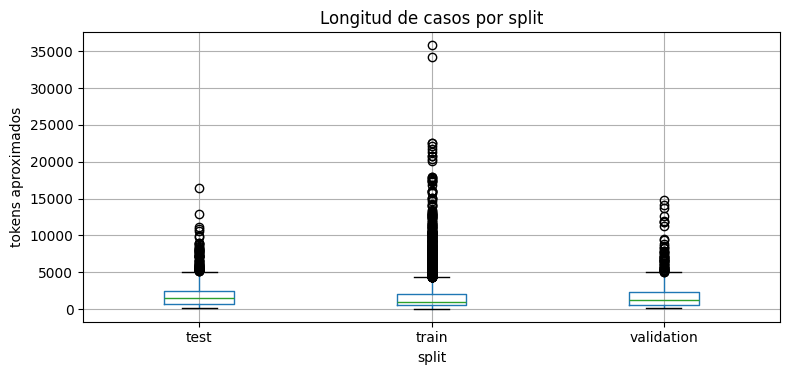

In [6]:
token_stats = cases.groupby('split')['n_tokens'].describe().reset_index()
token_stats.to_csv(METRICS / 'eda_token_stats_by_split.csv', index=False)
ax = cases.boxplot(column='n_tokens', by='split', figsize=(8,4))
plt.title('Longitud de casos por split')
plt.suptitle('')
plt.ylabel('tokens aproximados')
plt.tight_layout()
plt.savefig(FIGURES / 'eda_tokens_by_split.png', dpi=160)
token_stats


## Frecuencia de etiquetas

La tarea es multietiqueta y desbalanceada. Algunos articulos aparecen en muchos casos y otros tienen pocos ejemplos. Esto tiene tres consecuencias:

1. Un baseline que predice articulos frecuentes puede acertar parte del problema sin entender el texto.
2. `micro-F1` puede verse dominada por articulos comunes.
3. `macro-F1` es necesaria porque da el mismo peso a cada articulo y revela si el sistema ignora etiquetas raras.

Por eso el informe debe presentar al menos macro-F1, micro-F1 y Hamming loss.


,article_id,article_code,n_cases
3,3,6,6225
1,1,3,2210
2,2,5,2038
9,9,P1-1,1881
4,4,8,1397
0,0,2,774
6,6,10,611
8,8,14,510
7,7,11,244
5,5,9,101


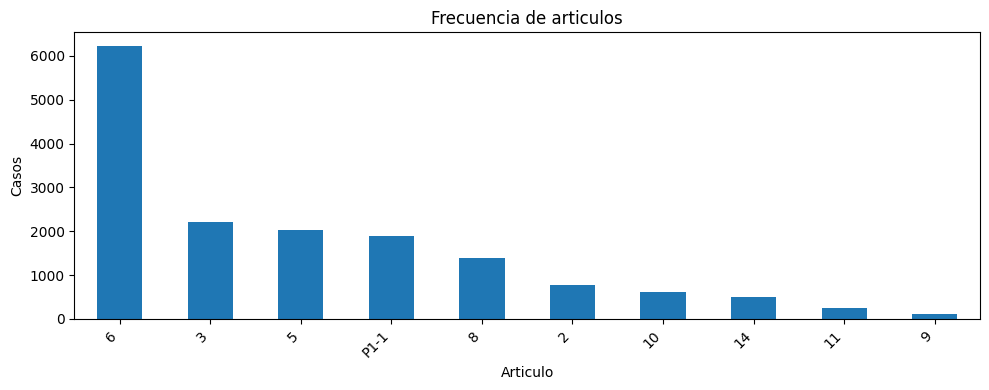

In [7]:
label_freq = labels.merge(articles, on='article_id', how='left').groupby(['article_id','article_code']).size().reset_index(name='n_cases')
label_freq = label_freq.sort_values('n_cases', ascending=False)
label_freq.to_csv(METRICS / 'eda_top_label_frequency.csv', index=False)
ax = label_freq.plot.bar(x='article_code', y='n_cases', legend=False, figsize=(10,4))
ax.set_title('Frecuencia de articulos')
ax.set_xlabel('Articulo')
ax.set_ylabel('Casos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES / 'eda_top_labels.png', dpi=160)
label_freq


## Ejemplo minimo: por que macro-F1 y micro-F1 cuentan historias distintas

En el ejemplo siguiente hay una etiqueta frecuente y una rara. Un modelo que acierta casi siempre la frecuente puede tener una micro-F1 razonable, pero su macro-F1 cae si falla la rara. Esto reproduce en pequeno el riesgo del dataset juridico.


In [8]:
from sklearn.metrics import f1_score, hamming_loss

y_true_demo = np.array([
    [1, 0],
    [1, 0],
    [1, 0],
    [0, 1],
])
y_pred_demo = np.array([
    [1, 0],
    [1, 0],
    [1, 0],
    [0, 0],
])

pd.DataFrame([{
    'micro_f1': f1_score(y_true_demo, y_pred_demo, average='micro', zero_division=0),
    'macro_f1': f1_score(y_true_demo, y_pred_demo, average='macro', zero_division=0),
    'hamming_loss': hamming_loss(y_true_demo, y_pred_demo),
}], index=['modelo_que_falla_la_etiqueta_rara'])


,micro_f1,macro_f1,hamming_loss
modelo_que_falla_la_etiqueta_rara,0.857143,0.5,0.125


## Temporalidad

El derecho cambia con el tiempo: aparecen nuevas interpretaciones, cambian los patrones de litigacion y algunos articulos pueden ganar o perder presencia. Si los splits del benchmark reflejan una separacion temporal, evaluar por periodos ayuda a detectar si el modelo pierde rendimiento cuando se aplica a casos mas recientes.

En este proyecto llamamos drift a dos fenomenos relacionados: drift de datos, cuando cambia la distribucion de longitudes o etiquetas; y drift de rendimiento, cuando las metricas del modelo se degradan entre periodos.


In [9]:
yearly_counts = cases.dropna(subset=['year']).groupby(['year','split']).size().reset_index(name='n_cases')
yearly_counts.to_csv(METRICS / 'eda_yearly_counts.csv', index=False)
if not yearly_counts.empty:
    pivot = yearly_counts.pivot(index='year', columns='split', values='n_cases').fillna(0)
    ax = pivot.plot(figsize=(9,4))
    ax.set_title('Casos por ano y split')
    ax.set_ylabel('casos')
    plt.tight_layout()
    plt.savefig(FIGURES / 'eda_cases_by_year.png', dpi=160)
yearly_counts.head()


,year,split,n_cases


## Coocurrencia de articulos

Un caso puede involucrar varios articulos. La matriz de coocurrencia identifica pares de articulos que aparecen juntos con frecuencia, lo que ayuda a interpretar falsos positivos y falsos negativos posteriores.

Por ejemplo, si dos articulos suelen coocurrir, el clasificador puede aprender patrones compartidos y predecir ambos aunque solo uno este anotado. Eso no siempre es un error trivial: en dominio juridico puede reflejar proximidad conceptual, ambiguedad de hechos o limitaciones del etiquetado.


In [10]:
case_article = labels.pivot_table(index='case_id', columns='article_id', values='value', aggfunc='max', fill_value=0)
cooc = case_article.T.dot(case_article)
cooc.to_csv(METRICS / 'eda_label_cooccurrence.csv')
cooc


article_id,0,1,2,3,4,5,6,7,8,9
article_id,,,,,,,,,,
0,774,367,261,122,70,3,13,3,58,41
1,367,2210,797,547,312,15,39,36,136,61
2,261,797,2038,570,247,10,37,58,67,40
3,122,547,570,6225,401,22,154,81,191,1290
4,70,312,247,401,1397,22,67,14,202,110
5,3,15,10,22,22,101,21,23,39,6
6,13,39,37,154,67,21,611,54,37,7
7,3,36,58,81,14,23,54,244,38,13
8,58,136,67,191,202,39,37,38,510,80


## Ejemplo minimo: como se interpreta una coocurrencia

En esta matriz ficticia, los articulos 5 y 6 aparecen juntos en dos casos. La diagonal cuenta cuantas veces aparece cada articulo; fuera de la diagonal se cuentan apariciones conjuntas.


In [11]:
toy_Y_for_cooc = pd.DataFrame(
    [[1, 1, 0], [1, 1, 0], [0, 1, 1], [0, 0, 1]],
    index=['case_1', 'case_2', 'case_3', 'case_4'],
    columns=['art_5', 'art_6', 'art_8'],
)
display(toy_Y_for_cooc)
display(toy_Y_for_cooc.T.dot(toy_Y_for_cooc))


,art_5,art_6,art_8
case_1,1,1,0
case_2,1,1,0
case_3,0,1,1
case_4,0,0,1


,art_5,art_6,art_8
art_5,2,2,0
art_6,2,3,1
art_8,0,1,2


In [12]:
dump_json({'stage': 'eda_notebook', 'timestamp_utc': datetime.now(timezone.utc).isoformat(), 'n_cases': int(len(cases)), 'outputs': ['eda_split_counts.csv','eda_token_stats_by_split.csv','eda_top_label_frequency.csv','eda_yearly_counts.csv']}, REPORTS / 'eda_status.json')
print('EDA completado')


EDA completado


In [13]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import json, re, sqlite3
from pathlib import Path

COLORS = {
    'navy': '#334155',
    'teal': '#8dd3c7',
    'blue': '#80b1d3',
    'coral': '#fb8072',
    'amber': '#fdb462',
    'purple': '#bebada',
    'gray': '#64748b',
    'lightgray': '#d9d9d9',
    'offwhite': '#f8fafc',
}

def paper_style():
    sns.set_palette('Set3')
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.edgecolor': COLORS['navy'],
        'axes.labelcolor': COLORS['navy'],
        'axes.titlecolor': COLORS['navy'],
        'axes.titlesize': 11,
        'axes.labelsize': 9,
        'xtick.color': COLORS['navy'],
        'ytick.color': COLORS['navy'],
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'font.size': 9,
        'legend.fontsize': 8,
        'savefig.facecolor': 'white',
        'savefig.bbox': 'tight',
    })

def save_paper_figure(fig, name):
    FIGURES.mkdir(parents=True, exist_ok=True)
    out = []
    for ext in ['pdf', 'png']:
        p = FIGURES / f'{name}.{ext}'
        fig.savefig(p, dpi=240 if ext == 'png' else None, bbox_inches='tight')
        out.append(p)
    plt.close(fig)
    return out

def box(ax, xy, w, h, text, face='white', edge=None, fontsize=9, weight='normal', color=None):
    patch = FancyBboxPatch(
        xy, w, h,
        boxstyle='round,pad=0.018,rounding_size=0.018',
        linewidth=1.15,
        edgecolor=edge or COLORS['navy'],
        facecolor=face,
    )
    ax.add_patch(patch)
    ax.text(
        xy[0] + w/2, xy[1] + h/2, text,
        ha='center', va='center',
        fontsize=fontsize,
        color=color or COLORS['navy'],
        fontweight=weight,
        linespacing=1.12,
    )
    return patch

def arrow(ax, start, end, color=None, rad=0.0, lw=1.5):
    patch = FancyArrowPatch(
        start, end,
        arrowstyle='-|>',
        mutation_scale=13,
        linewidth=lw,
        color=color or COLORS['gray'],
        connectionstyle=f'arc3,rad={rad}',
    )
    ax.add_patch(patch)
    return patch

def load_project_frames():
    conn = sqlite3.connect(DB)
    cases_df = pd.read_sql_query(
        'SELECT case_id, split, year, text_full, n_paragraphs, n_tokens FROM cases',
        conn,
    )
    labels_df = pd.read_sql_query(
        'SELECT case_id, article_id, value FROM case_labels WHERE value = 1',
        conn,
    )
    articles_df = pd.read_sql_query(
        'SELECT article_id, article_code, description FROM articles ORDER BY CAST(article_id AS INTEGER)',
        conn,
    )
    conn.close()
    labels_df['article_id'] = labels_df['article_id'].astype(str)
    articles_df['article_id'] = articles_df['article_id'].astype(str)
    return cases_df, labels_df, articles_df

paper_style()
cases_df, labels_df, articles_df = load_project_frames()
split_order = ['train', 'validation', 'test']
label_freq = (
    labels_df.merge(articles_df, on='article_id', how='left')
    .groupby(['article_id', 'article_code'])
    .size()
    .reset_index(name='n_cases')
    .sort_values('n_cases', ascending=False)
)
case_counts = labels_df.groupby('case_id').size().rename('n_articles').reset_index()
cooc = labels_df.pivot_table(index='case_id', columns='article_id', values='value', aggfunc='max', fill_value=0)
cooc = cooc.reindex(columns=articles_df['article_id'].tolist(), fill_value=0)
cooc_mat = cooc.T.dot(cooc)

fig = plt.figure(figsize=(13, 8))
gs = GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.28)
axes = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(3)]

split_counts = cases_df.groupby('split').size().reindex(split_order)
axes[0].bar(split_counts.index, split_counts.values, color=[COLORS['navy'], COLORS['teal'], COLORS['blue']])
axes[0].set_title('A. Tamaño por split')
axes[0].set_ylabel('casos')
for x, y in enumerate(split_counts.values):
    axes[0].text(x, y + 120, f'{int(y):,}'.replace(',', '.'), ha='center', fontsize=8, color=COLORS['navy'])

tokens = cases_df['n_tokens'].clip(lower=1)
bins = np.logspace(np.log10(tokens.min()), np.log10(tokens.max()), 42)
for split, color in zip(split_order, [COLORS['navy'], COLORS['teal'], COLORS['blue']]):
    values = cases_df.loc[cases_df['split'].eq(split), 'n_tokens'].clip(lower=1)
    axes[1].hist(values, bins=bins, histtype='step', linewidth=1.6, label=split, color=color)
axes[1].set_xscale('log')
axes[1].set_title('B. Longitud documental')
axes[1].set_xlabel('tokens aproximados, escala log')
axes[1].set_ylabel('casos')
axes[1].legend(frameon=False)

axes[2].bar(label_freq['article_code'], label_freq['n_cases'], color=COLORS['teal'])
axes[2].set_title('C. Frecuencia de artículos')
axes[2].set_ylabel('casos positivos')
axes[2].tick_params(axis='x', rotation=45)

im = axes[3].imshow(cooc_mat.values, cmap='Blues')
axes[3].set_title('D. Coocurrencia de artículos')
axes[3].set_xticks(range(len(articles_df)))
axes[3].set_yticks(range(len(articles_df)))
axes[3].set_xticklabels(articles_df['article_code'], rotation=45, ha='right')
axes[3].set_yticklabels(articles_df['article_code'])
fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

counts = case_counts['n_articles'].astype(int)
hist = counts.value_counts().reindex(range(int(counts.max()) + 1), fill_value=0)
axes[4].bar(hist.index, hist.values, color=COLORS['amber'])
axes[4].set_title('E. Artículos por caso')
axes[4].set_xlabel('número de artículos, casos etiquetados')
axes[4].set_ylabel('casos')
axes[4].axvline(counts.mean(), color=COLORS['coral'], linestyle='--', linewidth=1.4)
axes[4].text(counts.mean() + 0.08, hist.max() * 0.72, f'media = {counts.mean():.3f}', color=COLORS['coral'], fontsize=8)

sorted_freq = label_freq.sort_values('n_cases', ascending=False).reset_index(drop=True)
axes[5].plot(np.arange(1, len(sorted_freq) + 1), sorted_freq['n_cases'], marker='o', color=COLORS['purple'], linewidth=1.8)
axes[5].fill_between(np.arange(1, len(sorted_freq) + 1), sorted_freq['n_cases'], color=COLORS['purple'], alpha=0.12)
axes[5].set_title('F. Cola larga / etiquetas raras')
axes[5].set_xlabel('ranking de frecuencia')
axes[5].set_ylabel('casos positivos')
rare = sorted_freq.iloc[-1]
axes[5].annotate(
    f"más rara: art. {rare['article_code']}",
    xy=(len(sorted_freq), rare['n_cases']),
    xytext=(len(sorted_freq) - 4.5, rare['n_cases'] + sorted_freq['n_cases'].max() * 0.18),
    arrowprops=dict(arrowstyle='->', color=COLORS['gray']),
    fontsize=8,
    color=COLORS['navy'],
)
fig.suptitle('Figura 3. EDA multipanel: multietiqueta, desbalanceo, texto largo y coocurrencias', fontsize=14, fontweight='bold', color=COLORS['navy'])
written = save_paper_figure(fig, 'fig03_eda_multipanel')
print('\n'.join(str(p) for p in written))

C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\figures\fig03_eda_multipanel.pdf
C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\figures\fig03_eda_multipanel.png
